In [2]:

#model  : predictiing reversions
#supervised learning
#target : reversion degree, time of closure

#train separately on all 3 contracts : near mid and far.


#load train data : data/processed/events/{symbol}.csv as a dataframe
#val split not needed ig?

#generate whatever features
#train model, validate 

# use model to predict on 2025 data (test)
#load 2025 data
#get in correct format
#make predictions, log pnl, sharpe, win rate etc.

#features = {} (add features based on spread, vix, time, bid-ask)

#this whole feature vector should be an input to the model


#r_i = log (spread_i/spread_i-1)
#k = window size(fixed param)
#def mu_t(k,t,r):
    for i in (t-k+1,t,1): #ensure strictly : no lookahead bias
        mu_t += r_i
    mu_t/=k
    return mu_t

#similarly sigma_t = 1/(k-1) sum 
Volatility (standard deviation)
(\sigma_t = \sqrt{\frac{1}{k-1}\sum_{i=t-k+1}^{t}(r_i - \mu_t)^2})
Measures uncertainty; high σ implies unstable basis. 
2.1

Skewness (asymmetry of recent moves)
(\text{Skew}_t = \frac{1}{k}\sum\frac{(r_i-\mu_t)^3}{\sigma_t^3})

Kurtosis (tail risk / “spikiness”)
(\text{Kurt}_t = \frac{1}{k}\sum\frac{(r_i-\mu_t)^4}{\sigma_t^4})

#these are the basic features



In [3]:
# ---------- load events ----------
# One event row per detection: det/ext/res snapshots + session metadata.
# Columns described in src/events.ipynb
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, mean_absolute_error, confusion_matrix

root        = Path("..").resolve()
events_path = root / "data" / "processed" / "events"
MONTHS      = ["JAN","FEB","MAR","APR","MAY","JUN","JUL","AUG","SEP","OCT","NOV","DEC"]


def load_events_all():
    frames = []
    for f in sorted(events_path.glob("*.csv")):
        df = pd.read_csv(f, parse_dates=["det_timestamp", "ext_timestamp", "res_timestamp"])
        if not df.empty:
            frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


events = load_events_all()
print(f"events: {len(events)} rows across symbols {sorted(events['symbol'].unique())}")
print(events.groupby(["symbol", "klass"]).size().unstack(fill_value=0))


events: 2153 rows across symbols ['BAJFINANCE', 'RELIANCE']
klass       continuation  divergence  reversion
symbol                                         
BAJFINANCE           473         529        158
RELIANCE             485         418         90


In [4]:
# ---------- features, targets, contract-position ----------
# Contract position relative to the session month:
#   0 = near  (contract expires in the session's own month)
#   1 = mid   (next month)
#   2 = far   (month after that)
# Rows with position > 2 shouldnt exist; dropped if any.
#
# Targets (per spec):
#   klass          - categorical {reversion, divergence, continuation}
#   duration_sec   - res - det (seconds)
#   revert_delta   - |det_z| - |res_z|  (>0 means z came back toward zero)
#
# Features (all known AT detection, no forward look):
#   det_z_score, det_spread, side, dte, bucket
#   det_dist_std, det_dist_count, det_fut_ltq, det_oi_fut, det_ltq
#   det_fut_ba = det_fut_askprice - det_fut_bidprice  (fut bid-ask width)
#   det_eq_ba  = det_eq_askprice  - det_eq_bidprice   (eq  bid-ask width)

def _session_month_from_day(d):
    return pd.Timestamp(str(int(d))).month - 1                          # 0 based


events["session_month"]  = events["day_fut"].apply(_session_month_from_day)
events["contract_month"] = events["contract"].map({m: i for i, m in enumerate(MONTHS)})
events["position"]       = (events["contract_month"] - events["session_month"]) % 12

before = len(events)
events = events[events["position"].isin([0, 1, 2])].reset_index(drop=True)
print(f"kept {len(events)} / {before} events in positions 0..2")

# Targets
events["duration_sec"] = (events["res_timestamp"] - events["det_timestamp"]).dt.total_seconds()
events["revert_delta"] = events["det_z_score"].abs() - events["res_z_score"].abs()
events["spread_change"] = events["res_spread"] - events["det_spread"]

# Derived features
events["det_fut_ba"] = events["det_fut_askprice"] - events["det_fut_bidprice"]
events["det_eq_ba"]  = events["det_eq_askprice"]  - events["det_eq_bidprice"]

feature_cols = [
    "det_z_score", "det_spread", "side", "dte", "bucket",
    "det_dist_std", "det_dist_count",
    "det_fut_ltq", "det_oi_fut", "det_ltq",
    "det_fut_ba", "det_eq_ba",
]
print("feature cols:", feature_cols)
print(events.groupby(["position", "klass"]).size().unstack(fill_value=0))


kept 2080 / 2153 events in positions 0..2
feature cols: ['det_z_score', 'det_spread', 'side', 'dte', 'bucket', 'det_dist_std', 'det_dist_count', 'det_fut_ltq', 'det_oi_fut', 'det_ltq', 'det_fut_ba', 'det_eq_ba']
klass     continuation  divergence  reversion
position                                     
0                   29          56        124
1                  313         412         98
2                  566         456         26


In [5]:
# time-based train / test split
# All available events span 2022-2024 (processed data upper bound).
# Train on events through 2023, held-out on 2024. No random shuffle -- strictly
# causal split.

events["year"] = events["det_timestamp"].dt.year
train = events[events["year"] <= 2023].reset_index(drop=True)
test  = events[events["year"] == 2024].reset_index(drop=True)
print(f"train: {len(train)} events (<=2023)   test: {len(test)} events (2024)")
print("train klass:", dict(train['klass'].value_counts()))
print("test  klass:", dict(test['klass'].value_counts()))


train: 1349 events (<=2023)   test: 731 events (2024)
train klass: {'divergence': np.int64(604), 'continuation': np.int64(534), 'reversion': np.int64(211)}
test  klass: {'continuation': np.int64(374), 'divergence': np.int64(320), 'reversion': np.int64(37)}


In [6]:
# train per contract position
# 3 models per position: classifier for klass, regressors for duration & revert.
#one triplet per position (0=near,1=mid, 2=far)

def _clean(df, cols):
    tgt = ["klass", "duration_sec", "revert_delta"]
    return df.dropna(subset=cols + tgt)


def train_position(train_df, position, feature_cols):
    sub = _clean(train_df[train_df["position"] == position], feature_cols)
    if len(sub) < 30:
        print(f"position={position}: only {len(sub)} rows, skipping")
        return None
    X      = sub[feature_cols].to_numpy()
    y_klas = sub["klass"].to_numpy()
    y_dur  = sub["duration_sec"].to_numpy()
    y_rev  = sub["revert_delta"].to_numpy()

    clf     = RandomForestClassifier(n_estimators=200, max_depth=10,
                                     n_jobs=-1, random_state=42).fit(X, y_klas)
    reg_dur = RandomForestRegressor (n_estimators=200, max_depth=10,
                                     n_jobs=-1, random_state=42).fit(X, y_dur)
    reg_rev = RandomForestRegressor (n_estimators=200, max_depth=10,
                                     n_jobs=-1, random_state=42).fit(X, y_rev)
    klass_cnt = dict(pd.Series(y_klas).value_counts())
    print(f"position={position}: trained on {len(sub)} events  klass={klass_cnt}")
    return clf, reg_dur, reg_rev


models = {p: train_position(train, p, feature_cols) for p in (0, 1, 2)}


position=0: trained on 160 events  klass={'reversion': np.int64(110), 'divergence': np.int64(33), 'continuation': np.int64(17)}
position=1: trained on 559 events  klass={'divergence': np.int64(288), 'continuation': np.int64(187), 'reversion': np.int64(84)}
position=2: trained on 630 events  klass={'continuation': np.int64(330), 'divergence': np.int64(283), 'reversion': np.int64(17)}


In [7]:
# Classification report for klass + MAE for duration and revert_delta on the
# held-out (test) slice, per contract position.

def evaluate(test_df, position, feature_cols, models):
    sub = _clean(test_df[test_df["position"] == position], feature_cols)
    if sub.empty:
        print(f"position={position}: no test rows"); return None
    clf, reg_dur, reg_rev = models[position]
    X = sub[feature_cols].to_numpy()
    pred_k   = clf.predict(X)
    pred_dur = reg_dur.predict(X)
    pred_rev = reg_rev.predict(X)
    print(f"\n=== position={position}  (n={len(sub)}) ===")
    print(classification_report(sub["klass"], pred_k, zero_division=0))
    print(f"duration_sec   MAE = {mean_absolute_error(sub['duration_sec'], pred_dur):8.1f}")
    print(f"revert_delta   MAE = {mean_absolute_error(sub['revert_delta'], pred_rev):8.3f}")
    sub = sub.copy()
    sub["pred_klass"] = pred_k
    sub["pred_dur"]   = pred_dur
    sub["pred_rev"]   = pred_rev
    return sub


evals = {p: evaluate(test, p, feature_cols, models) for p in (0, 1, 2)}



=== position=0  (n=49) ===
              precision    recall  f1-score   support

continuation       1.00      0.33      0.50        12
  divergence       0.57      0.57      0.57        23
   reversion       0.32      0.50      0.39        14

    accuracy                           0.49        49
   macro avg       0.63      0.47      0.48        49
weighted avg       0.60      0.49      0.50        49

duration_sec   MAE =   6961.2
revert_delta   MAE =    0.982

=== position=1  (n=264) ===
              precision    recall  f1-score   support

continuation       0.68      0.68      0.68       126
  divergence       0.70      0.75      0.72       124
   reversion       0.50      0.14      0.22        14

    accuracy                           0.69       264
   macro avg       0.63      0.53      0.54       264
weighted avg       0.68      0.69      0.68       264

duration_sec   MAE =   6972.9
revert_delta   MAE =    0.517

=== position=2  (n=418) ===
              precision    recal


=== backtest (held-out) ===
position=0 (near): trades=22  win_rate=63.64%  mean_pnl=+0.0714%  std=0.2679  sharpe≈1.25  total_pnl=+1.570%
position=1 (mid): trades=4  win_rate=100.00%  mean_pnl=+0.2181%  std=0.1906  sharpe≈2.29  total_pnl=+0.872%
position=2 (far): model never predicted reversion -> 0 trades


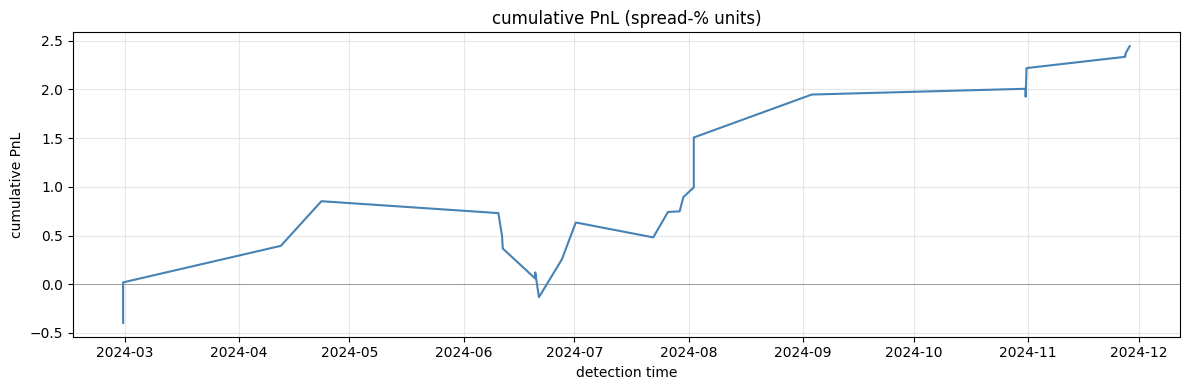

In [8]:
## Trade rule: open a trade at detection iff the classifier predicts 'reversion'.
# For side=+1 (spread abnormally high) we short the spread; for side=-1 we go long.
# PnL per event = -side * (res_spread - det_spread), in spread-percent units.
# Close at the resolution time (res_*). No slippage / no financing.

def backtest(eval_df, label):
    if eval_df is None or eval_df.empty:
        print(f"{label}: no eval data"); return None
    trades = eval_df[eval_df["pred_klass"] == "reversion"].copy()
    if trades.empty:
        print(f"{label}: model never predicted reversion -> 0 trades"); return None
    trades["pnl"] = -trades["side"] * trades["spread_change"]
    n      = len(trades)
    wins   = (trades["pnl"] > 0).sum()
    mean_p = trades["pnl"].mean()
    std_p  = trades["pnl"].std(ddof=1) if n > 1 else np.nan
    sharpe = (mean_p / std_p * np.sqrt(n)) if std_p and std_p > 0 else np.nan
    total  = trades["pnl"].sum()
    print(f"{label}: trades={n}  win_rate={wins/n:.2%}  mean_pnl={mean_p:+.4f}%  "
          f"std={std_p:.4f}  sharpe≈{sharpe:.2f}  total_pnl={total:+.3f}%")
    return trades


print("\n=== backtest (held-out) ===")
all_trades = []
for p, label in zip((0, 1, 2), ("near", "mid", "far")):
    t = backtest(evals.get(p), f"position={p} ({label})")
    if t is not None:
        all_trades.append(t)

if all_trades:
    combined = pd.concat(all_trades, ignore_index=True).sort_values("det_timestamp")
    equity = combined["pnl"].cumsum()
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(combined["det_timestamp"], equity, color="steelblue")
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.set_title("cumulative PnL (spread-% units)")
    ax.set_xlabel("detection time"); ax.set_ylabel("cumulative PnL")
    ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


In [ ]:
#for 2025 data : just load from the raw data and see how it works. run the processing pipeline on 2025 data separately, store as processed/test/ . store the earlier data at processed/train/